# Fragmented Identity Resolution Pipeline

End-to-end pipeline for entity resolution on NC Voter Registration data.

## Pipeline stages:
1. **Load & Preprocess** — Normalize names, addresses, ZIP codes
2. **Silver/Gold Label Construction** — Build proxy ground truth from exact-match groups
3. **Pair Generation** — Positive, hard-negative, and block-negative pairs with entity-level splitting
4. **Synthetic Augmentation** — Rule-based perturbations (replacing LLM approach)
5. **Model Training** — Siamese char-CNN for pairwise match scoring
6. **Evaluation** — Precision, Recall, F1, AUC, calibration analysis

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"/Users/dharineeshsomisetty/Downloads/spring-2026-deep-learning-fragmented-id-resolution-88eca331f655245fa4bd48816e2d2968f5ba43a3")
OLD_PROJECT_ROOT = Path(r"/Users/dharineeshsomisetty/Downloads/deep-learning-fragmented-id-resolution")
os.chdir(PROJECT_ROOT)

# Force imports to resolve from the current repo, not an older sibling checkout.
sys.path = [p for p in sys.path if Path(p).resolve() != OLD_PROJECT_ROOT]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

for name in [k for k in list(sys.modules) if k == "src" or k.startswith("src.")]:
    del sys.modules[name]

from src.preprocessing import (
    normalize_dataframe,
    normalize_name,
    normalize_suffix,
    normalize_single_street_address,
    normalize_zip5,
)
from src.label_construction import (
    build_silver_groups,
    validate_gold_groups,
    load_existing_pairs,
)
from src.pair_generation import (
    generate_gold_positive_pairs,
    generate_hard_negative_pairs,
    generate_block_negatives,
    generate_name_collision_negatives,
    generate_near_miss_negatives,
    generate_demographic_negatives,
    pairs_from_dpl,
    pairs_from_ndpl,
    combine_pairs,
    entity_level_split,
    split_record_ids_by_entity,
)
from src.augmentation import (
    augment_dataframe,
    generate_augmented_pairs,
    generate_augmented_negative_pairs,
)
from src.baseline import (
    train_pair_classifier,
    evaluate_pair_classifier,
    save_pair_classifier,
    load_pair_classifier,
    predict_pair_probabilities,
    score_candidate_pairs,
    find_duplicates_with_baseline,
)
from src.blocking import block_and_generate_candidates, build_block_index

print(f"Notebook configured for the classical supervised baseline.\nProject root: {PROJECT_ROOT}")

Notebook configured for the classical supervised baseline.
Project root: /Users/dharineeshsomisetty/Downloads/spring-2026-deep-learning-fragmented-id-resolution-88eca331f655245fa4bd48816e2d2968f5ba43a3


In [2]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    normalize_dataframe,
    normalize_name,
    normalize_suffix,
    normalize_single_street_address,
    normalize_zip5,
)
from src.label_construction import (
    build_silver_groups,
    validate_gold_groups,
    load_existing_pairs,
)
from src.pair_generation import (
    generate_gold_positive_pairs,
    generate_hard_negative_pairs,
    generate_block_negatives,
    generate_name_collision_negatives,
    generate_near_miss_negatives,
    generate_demographic_negatives,
    pairs_from_dpl,
    pairs_from_ndpl,
    combine_pairs,
    entity_level_split,
    split_record_ids_by_entity,
)
from src.augmentation import (
    augment_dataframe,
    generate_augmented_pairs,
    generate_augmented_negative_pairs,
)
from src.baseline import (
    train_pair_classifier,
    evaluate_pair_classifier,
    save_pair_classifier,
    load_pair_classifier,
    predict_pair_probabilities,
    score_candidate_pairs,
    find_duplicates_with_baseline,
)
from src.blocking import block_and_generate_candidates, build_block_index

print("Notebook configured for the classical supervised baseline.")

Notebook configured for the classical supervised baseline.


## 1. Load and Preprocess Data

We load the raw NCVoters TSV (Alamance County, ~14K records) and normalize:
- **Names**: uppercase, strip punctuation, collapse whitespace
- **Addresses**: normalize street suffixes (STREET→ST), directionals (NORTH→N), unit markers
- **ZIP**: extract ZIP5
- **Birth year**: derived from `age` column (snapshot year 2018)

In [3]:
# Load raw data
raw_df = pd.read_csv(
    "ncvoters.tsv",
    sep="\t",
    dtype=str,
    na_filter=False,
    encoding="utf-8",
)
raw_df = raw_df.loc[:, ~raw_df.columns.str.contains(r"^Unnamed")]
print(f"Raw records: {len(raw_df):,}")
print(f"Columns: {list(raw_df.columns[:10])}... ({len(raw_df.columns)} total)")

Raw records: 14,183
Columns: ['NC_house_abbrv', 'NC_house_desc', 'NC_senate_abbrv', 'NC_senate_desc', 'absent_ind', 'age', 'age_group', 'area_cd', 'birth_place', 'cancellation_dt']... (91 total)


In [4]:
# Normalize
df = normalize_dataframe(raw_df, snapshot_year=2018)
print(f"Normalized records: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Normalized records: 14,183
Columns: ['id', 'first_name', 'middle_name', 'last_name', 'name_suffix', 'street_address', 'city', 'zip5', 'birth_year']


,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
0,277,DOMENIQUE,ANNA,GRAMOLINI,,1313 ELDORADO ST,BURLINGTON,27217,1987
1,566,DEBORAH,,WELLS,,1908 GLENKIRK DR,BURLINGTON,27215,1969
2,1369,EVAN,NATHANIEL,WORKMAN,,6378 MT HERMON ROCK CREEK RD,SNOW CAMP,27349,1998
3,1567,ALYSSA,DANIELLE,MARION,,852 S SPRING ST,BURLINGTON,27215,1988
4,1583,LACOSTA,GAIL,WILLIAMSON,,2248 MAY DR,BURLINGTON,27215,1981
5,1740,JAKIA,TYKEL,SELLARS,,1120 ELWOOD ST,BURLINGTON,27217,1995
6,1959,WILLIAM,WELDON,JONES,,223 SHADOWBROOK DR,BURLINGTON,27215,1975
7,5842,REBECCA,CHEEK,MURRAY,,1231 SHAMROCK DR,BURLINGTON,27215,1948
8,15124,CLAYTON,HOLLOWAY,SPIVEY,,809 SIDEVIEW ST,GRAHAM,27253,1955
9,15198,MARALYNE,,SANCHEZ,,523 AVON AVE,BURLINGTON,27215,1968


In [5]:
# Quick data quality check
print("=== Data Quality ===")
for col in df.columns:
    non_empty = (df[col].astype(str).str.strip() != "").sum()
    print(f"  {col:20s}: {non_empty:>6,} / {len(df):,} ({100*non_empty/len(df):.1f}%)")

=== Data Quality ===
  id                  : 14,183 / 14,183 (100.0%)
  first_name          : 14,183 / 14,183 (100.0%)
  middle_name         : 13,366 / 14,183 (94.2%)
  last_name           : 14,183 / 14,183 (100.0%)
  name_suffix         :    747 / 14,183 (5.3%)
  street_address      : 14,183 / 14,183 (100.0%)
  city                : 14,182 / 14,183 (100.0%)
  zip5                : 14,182 / 14,183 (100.0%)
  birth_year          : 14,183 / 14,183 (100.0%)


## 2. Construct Silver & Gold Labels

**Silver groups**: exact match on `(first, middle, last, suffix, street, city, zip5)` → records with identical normalized identity fields but distinct internal IDs.

**Gold groups**: silver groups validated by `birth_year` — all members share the same birth year = high-confidence same person.

**Birth-year conflicts**: silver groups where birth years disagree = **hard negatives** (likely different people at same address, e.g., parent/child).

In [6]:
# Build silver groups
df = build_silver_groups(df)

n_silver = (df["silver_group_id"] >= 0).sum()
n_groups = df[df["silver_group_id"] >= 0]["silver_group_id"].nunique()
print(f"Records in silver duplicate groups: {n_silver:,}")
print(f"Number of silver groups: {n_groups:,}")

Records in silver duplicate groups: 950
Number of silver groups: 448


In [7]:
# Validate gold groups
gold_df, conflict_df, stats = validate_gold_groups(df)

print("=== Label Construction Stats ===")
for k, v in stats.items():
    print(f"  {k}: {v}")

print(f"\nGold positive records: {len(gold_df):,}")
print(f"Hard negative records (birth-year conflict): {len(conflict_df):,}")

=== Label Construction Stats ===
  n_silver_groups: 448
  n_gold_groups: 442
  n_conflict_groups: 6
  n_missing_by_groups: 0
  n_gold_records: 934
  n_conflict_records: 16

Gold positive records: 934
Hard negative records (birth-year conflict): 16


In [8]:
# Inspect a few gold groups
print("=== Sample Gold Group (same person, high confidence) ===")
sample_gold_gid = gold_df["silver_group_id"].unique()[0]
display(gold_df[gold_df["silver_group_id"] == sample_gold_gid][
    ["id", "first_name", "middle_name", "last_name", "street_address", "city", "zip5", "birth_year"]
])

if len(conflict_df) > 0:
    print("\n=== Sample Conflict Group (same name+address, different birth year → hard negative) ===")
    sample_conflict_gid = conflict_df["silver_group_id"].unique()[0]
    display(conflict_df[conflict_df["silver_group_id"] == sample_conflict_gid][
        ["id", "first_name", "middle_name", "last_name", "street_address", "city", "zip5", "birth_year"]
    ])

=== Sample Gold Group (same person, high confidence) ===


,id,first_name,middle_name,last_name,street_address,city,zip5,birth_year
18,22467,CANDACE,HATCH,WILSON,2489 MILLBROOK DR,HAW RIVER,27258,1973
99,92641,CANDACE,HATCH,WILSON,2489 MILLBROOK DR,HAW RIVER,27258,1973
183,162402,CANDACE,HATCH,WILSON,2489 MILLBROOK DR,HAW RIVER,27258,1973



=== Sample Conflict Group (same name+address, different birth year → hard negative) ===


,id,first_name,middle_name,last_name,street_address,city,zip5,birth_year
802,648114,ROGER,WILLIAM,HAYES,21 BROOKSTONE PL,CANDLER,28715,1942
838,671247,ROGER,WILLIAM,HAYES,21 BROOKSTONE PL,CANDLER,28715,1942
871,694894,ROGER,WILLIAM,HAYES,21 BROOKSTONE PL,CANDLER,28715,1943


## 3. Generate Training & Evaluation Pairs

**Sources:**
- Gold groups → positive pairs (`label=1`)
- Birth-year conflict groups → hard negative pairs (`label=0`)
- Block negatives / name-collision negatives / near-miss negatives → realistic hard negatives
- Existing DPL/NDPL ground truth from the HPI dataset

**Critical change:** the split is now done by **duplicate-connected entity components**.
Any pair that would bridge train and test entities is dropped, so record IDs do not leak across splits.


In [9]:
# Generate pairs from our silver/gold construction
gold_pos_pairs = generate_gold_positive_pairs(gold_df)
hard_neg_pairs = generate_hard_negative_pairs(conflict_df)
block_neg_pairs = generate_block_negatives(df, n_negatives=5000)

# Hard negatives: same first+last name, different birth year -> different people
name_collision_neg_pairs = generate_name_collision_negatives(df, n_negatives=3000)

# Near-miss negatives: different silver groups sharing 4+ of 7 signature fields
near_miss_neg_pairs = generate_near_miss_negatives(df, n_negatives=2000, min_shared_fields=4)

# Adversarial negatives: same birth_year + ZIP area, completely different names.
# Teaches model that sharing demographics is NOT sufficient — names must also
# be plausibly similar.  Without these the classifier over-weights birth_year_eq
# and zip5_eq, causing false clusters of unrelated people.
demographic_neg_pairs = generate_demographic_negatives(df, n_negatives=5000)

print(f"Gold positive pairs:           {len(gold_pos_pairs):,}")
print(f"Hard negative pairs:           {len(hard_neg_pairs):,}")
print(f"Block negative pairs:          {len(block_neg_pairs):,}")
print(f"Name-collision negative pairs: {len(name_collision_neg_pairs):,}")
print(f"Near-miss negative pairs:      {len(near_miss_neg_pairs):,}")
print(f"Demographic negative pairs:    {len(demographic_neg_pairs):,}")

Gold positive pairs:           550
Hard negative pairs:           10
Block negative pairs:          3,915
Name-collision negative pairs: 201
Near-miss negative pairs:      4
Demographic negative pairs:    5,000


In [10]:
# Load existing DPL/NDPL ground truth
dpl, ndpl = load_existing_pairs("ncvoters_DPL.tsv", "ncvoters_NDPL.tsv")
dpl_pairs = pairs_from_dpl(dpl)
ndpl_pairs = pairs_from_ndpl(ndpl, max_pairs=10000)

print(f"DPL positive pairs: {len(dpl_pairs):,}")
print(f"NDPL negative pairs (sampled): {len(ndpl_pairs):,}")

DPL positive pairs: 9,819
NDPL negative pairs (sampled): 10,000


In [11]:
# Combine all pair sources
all_pairs = combine_pairs(
    gold_pos_pairs, hard_neg_pairs, block_neg_pairs,
    name_collision_neg_pairs, near_miss_neg_pairs,
    demographic_neg_pairs,
    dpl_pairs, ndpl_pairs,
)

print(f"\nTotal combined pairs: {len(all_pairs):,}")
print(f"  Positives (label=1): {(all_pairs['label'] == 1).sum():,}")
print(f"  Negatives (label=0): {(all_pairs['label'] == 0).sum():,}")
print(f"\nPair sources:")
print(all_pairs.groupby(["source", "label"]).size().unstack(fill_value=0))


Total combined pairs: 28,847
  Positives (label=1): 9,736
  Negatives (label=0): 19,111

Pair sources:
label                       0     1
source                             
block_negative           3905     0
demographic_negative     4999     0
dpl                         0  9186
gold                        0   550
hard_negative              10     0
name_collision_negative   195     0
ndpl                     9998     0
near_miss_negative          4     0


In [12]:
# Entity-level train/test split (strictly no record leakage)
train_ids, test_ids = split_record_ids_by_entity(all_pairs, test_size=0.2)
train_pairs, test_pairs = entity_level_split(all_pairs, df, test_size=0.2)

overlap_ids = (set(train_pairs["id1"]) | set(train_pairs["id2"])) & (set(test_pairs["id1"]) | set(test_pairs["id2"]))
dropped_pairs = len(all_pairs) - len(train_pairs) - len(test_pairs)

print(f"Train pairs: {len(train_pairs):,} (pos={int((train_pairs['label']==1).sum())}, neg={int((train_pairs['label']==0).sum())})")
print(f"Test  pairs: {len(test_pairs):,} (pos={int((test_pairs['label']==1).sum())}, neg={int((test_pairs['label']==0).sum())})")
print(f"Overlap record IDs across splits: {len(overlap_ids):,}")
print(f"Cross-split pairs dropped: {dropped_pairs:,}")


Train pairs: 20,101 (pos=7817, neg=12284)
Test  pairs: 2,705 (pos=1919, neg=786)
Overlap record IDs across splits: 0
Cross-split pairs dropped: 6,041


## 4. Synthetic Augmentation (Split-Safe)

We keep the rule-based perturbations, but seeds are now restricted by split:
- training augmentations come only from `train_ids`
- test/stress augmentations come only from `test_ids`

This preserves the anti-overfitting evaluation while avoiding augmentation leakage.


In [13]:
# Generate training augmentations (uses TRAIN_TYPES only, train split only)
train_seed, train_synthetic = augment_dataframe(
    df,
    mode="train",
    frac=0.15,
    n_variants_per_record=2,
    n_perturbations_per_variant=2,
    random_state=42,
    seed_ids=train_ids,
)

print("Training augmentation:")
print(f"  Seed records: {len(train_seed):,}")
print(f"  Synthetic records: {len(train_synthetic):,}")
print()
all_ptypes = train_synthetic["perturbation_types"].str.split(",").explode()
print("Perturbation type distribution (training):")
print(all_ptypes.value_counts().to_string() if len(all_ptypes.dropna()) else "  No perturbations generated")


Training augmentation:
  Seed records: 1,683
  Synthetic records: 3,366

Perturbation type distribution (training):
perturbation_types
typo_swap           1986
whitespace_noise    1087
suffix_swap         1050
blank_middle         828
drop_middle          807
initial              726
nickname             240
unit_format            8


In [14]:
# Show some augmentation examples
print("=== Augmentation Examples ===")
fields = ["first_name", "middle_name", "last_name", "street_address", "city", "zip5"]

for seed_id in train_seed["id"].head(5):
    seed_row = train_seed[train_seed["id"] == seed_id].iloc[0]
    syn_rows = train_synthetic[train_synthetic["seed_id"] == seed_id]
    
    print(f"\n--- Seed: {seed_id} ---")
    print(f"  Original: {' | '.join(str(seed_row[f]) for f in fields)}")
    for _, syn_row in syn_rows.iterrows():
        ptypes = syn_row['perturbation_types']
        print(f"  Variant:  {' | '.join(str(syn_row[f]) for f in fields)}  [{ptypes}]")

=== Augmentation Examples ===

--- Seed: 12380740 ---
  Original: ANNA | KATHERINE | SHELTON | 102 ST BRIDES CT | CARY | 27518
  Variant:  ANNA | K | SHELTON | 102  ST BRIDES CT | CARY | 27518  [initial,whitespace_noise]
  Variant:  ANNA | KATHERINE | SHLETON | 102 ST  BRIDES CT | CARY | 27518  [whitespace_noise,typo_swap]

--- Seed: 9481522 ---
  Original: CHRISTOPHER | RANDY | HOLMES | 514 FIRE TOWER RD | RICHLANDS | 28574
  Variant:  TOPHER | RANDY | HOLMES | 514  FIRE TOWER RD | RICHLANDS | 28574  [whitespace_noise,nickname]
  Variant:  CHRISTOPHER |  | HOLMES | 514 FIRE TOWER ROAD | RICHLANDS | 28574  [suffix_swap,blank_middle]

--- Seed: 7250433 ---
  Original: JENNIFER | LYNN | BAISDEN | 836 SUGAR HILL RD | OLD FORT | 28762
  Variant:  JENNIFER | L | BAIDSEN | 836 SUGAR HILL RD | OLD FORT | 28762  [initial,typo_swap]
  Variant:  JEN | LYNN | BAISDEN | 836 SUGAR  HILL RD | OLD FORT | 28762  [whitespace_noise,nickname]

--- Seed: 6121238 ---
  Original: SHEILA | BAYSDEN | GUTHRIE 

In [15]:
# Generate test augmentations (test split only)
test_seed, test_synthetic = augment_dataframe(
    df,
    mode="test",
    frac=0.05,
    n_variants_per_record=2,
    n_perturbations_per_variant=2,
    random_state=99,
    seed_ids=test_ids,
)

stress_seed, stress_synthetic = augment_dataframe(
    df,
    mode="test_only",
    frac=0.03,
    n_variants_per_record=2,
    n_perturbations_per_variant=2,
    random_state=123,
    seed_ids=test_ids,
)

print(f"Test augmentation: {len(test_synthetic):,} synthetic records")
print(f"Stress-test augmentation (held-out types only): {len(stress_synthetic):,} synthetic records")


Test augmentation: 280 synthetic records
Stress-test augmentation (held-out types only): 168 synthetic records


In [16]:
# Add synthetic augmented records to the record pool and generate their pairs
train_synthetic["id"] = [f"syn_train_{i}" for i in range(len(train_synthetic))]
test_synthetic["id"] = [f"syn_test_{i}" for i in range(len(test_synthetic))]
stress_synthetic["id"] = [f"syn_stress_{i}" for i in range(len(stress_synthetic))]

aug_train_pairs = generate_augmented_pairs(train_seed, train_synthetic)
aug_test_pairs = generate_augmented_pairs(test_seed, test_synthetic)
aug_stress_pairs = generate_augmented_pairs(stress_seed, stress_synthetic)

train_neg_pairs = train_pairs[train_pairs["label"] == 0]
aug_neg_train_pairs, aug_neg_train_synthetic = generate_augmented_negative_pairs(
    train_neg_pairs,
    df,
    mode="train",
    frac=0.4,
    id_prefix="syn_neg_train",
)
# `generate_augmented_negative_pairs` already assigns paired synthetic IDs
# like `syn_neg_train_0_a` / `syn_neg_train_0_b`; do not overwrite them.

print(f"Augmented positive train pairs:  {len(aug_train_pairs):,}")
print(f"Augmented positive test pairs:   {len(aug_test_pairs):,}")
print(f"Augmented stress test pairs:     {len(aug_stress_pairs):,}")
print(f"Augmented negative train pairs:  {len(aug_neg_train_pairs):,}")


Augmented positive train pairs:  3,366
Augmented positive test pairs:   280
Augmented stress test pairs:     168
Augmented negative train pairs:  4,914


In [17]:
# Build expanded record pool (original + all synthetic)
all_records = pd.concat(
    [
        df,
        train_synthetic.reindex(columns=df.columns),
        test_synthetic.reindex(columns=df.columns),
        stress_synthetic.reindex(columns=df.columns),
        aug_neg_train_synthetic.reindex(columns=df.columns),
    ],
    ignore_index=True,
)

final_train_pairs = pd.concat([train_pairs, aug_train_pairs, aug_neg_train_pairs], ignore_index=True)
final_test_pairs = pd.concat([test_pairs, aug_test_pairs], ignore_index=True)

print(f"All records (original + synthetic): {len(all_records):,}")
print(f"Final train pairs: {len(final_train_pairs):,}")
print(f"  pos={int((final_train_pairs['label']==1).sum())}, neg={int((final_train_pairs['label']==0).sum())}")
print(f"Final test pairs:  {len(final_test_pairs):,}")
print(f"Stress test pairs: {len(aug_stress_pairs):,}")


All records (original + synthetic): 27,825
Final train pairs: 28,381
  pos=11183, neg=17198
Final test pairs:  2,985
Stress test pairs: 168


## 5. Train Classical Pair Classifier

We replace the Siamese char-CNN with a supervised feature-based matcher.

Models compared here:
- `logreg`: logistic regression on field-level similarity features
- `hgbt`: histogram gradient boosting tree baseline

We will use the faster `logreg` model as the default deployment model unless the tree baseline provides a compelling gain.


In [18]:
print("Training corpus summary")
print(f"  Records available for featurization: {len(all_records):,}")
print(f"  Training pairs: {len(final_train_pairs):,}")
print(f"  Test pairs:     {len(final_test_pairs):,}")
print(f"  Stress pairs:   {len(aug_stress_pairs):,}")
print()
print("Sample training pair:")
print(final_train_pairs.iloc[0])


Training corpus summary
  Records available for featurization: 27,825
  Training pairs: 28,381
  Test pairs:     2,985
  Stress pairs:   168

Sample training pair:
id1         9046619
id2         9111856
label             1
source         gold
group_id          6
Name: 0, dtype: object


In [19]:
# Train both classical baselines and compare on the standard test set
trained_models = {}
comparison_rows = []

for model_type in ["logreg", "hgbt"]:
    bundle = train_pair_classifier(final_train_pairs, all_records, model_type=model_type)
    metrics = evaluate_pair_classifier(bundle, final_test_pairs, all_records)
    trained_models[model_type] = bundle
    comparison_rows.append({"model_type": model_type, **metrics})
    print()
    print(f"=== {model_type} ===")
    for key, value in metrics.items():
        print(f"  {key:10s}: {value:.4f}")

comparison_df = pd.DataFrame(comparison_rows).sort_values(["f1", "auc"], ascending=False)
comparison_df



=== logreg ===
  accuracy  : 0.9940
  precision : 0.9977
  recall    : 0.9941
  f1        : 0.9959
  auc       : 0.9997
  fpr       : 0.0064
  fnr       : 0.0059

=== hgbt ===
  accuracy  : 0.9879
  precision : 0.9986
  recall    : 0.9850
  f1        : 0.9918
  auc       : 0.9998
  fpr       : 0.0038
  fnr       : 0.0150


,model_type,accuracy,precision,recall,f1,auc,fpr,fnr
0,logreg,0.99397,0.997718,0.994088,0.995900,0.999744,0.006361,0.005912
1,hgbt,0.98794,0.998617,0.984993,0.991758,0.999814,0.003817,0.015007


In [20]:
# Choose the deployment model
SELECTED_MODEL_TYPE = "logreg"
baseline_model = trained_models[SELECTED_MODEL_TYPE]
BASELINE_MODEL_PATH = "baseline_model.joblib"
DEPLOYMENT_THRESHOLD = 0.5

print(f"Selected model for deployment: {SELECTED_MODEL_TYPE}")
print("Reason: logistic regression is nearly tied with the tree model here, but is simpler and cheaper at Mecklenburg scale.")


Selected model for deployment: logreg
Reason: logistic regression is nearly tied with the tree model here, but is simpler and cheaper at Mecklenburg scale.


In [21]:
# If logistic regression is selected, inspect the strongest learned coefficients
if SELECTED_MODEL_TYPE == "logreg":
    classifier = baseline_model.model.named_steps["classifier"]
    coef_df = pd.DataFrame(
        {"coefficient": classifier.coef_[0]},
        index=baseline_model.feature_columns,
    )
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    display(coef_df.sort_values("abs_coefficient", ascending=False).head(15))
else:
    print("Coefficient inspection is only available for the logistic-regression baseline.")


,coefficient,abs_coefficient
full_name_ratio,4.147535,4.147535
birth_year_eq,3.902380,3.902380
first_name_ratio,2.111719,2.111719
full_record_ratio,1.859466,1.859466
house_number_eq,1.080840,1.080840
last_name_ratio,-1.008094,1.008094
birth_year_absdiff,-0.919435,0.919435
middle_name_ratio,-0.883672,0.883672
city_ratio,-0.800709,0.800709
zip5_eq,-0.731366,0.731366


## 6. Evaluation

We evaluate the selected baseline on:
1. **Standard test set** — original held-out pairs plus split-safe augmented positives
2. **Stress test** — only held-out perturbation types from held-out test records

The standard test set is the main metric. The stress set is positive-only, so its most useful number is recall at the chosen threshold.


In [22]:
# Standard test evaluation for the selected baseline
print("=== Standard Test Evaluation ===")
test_metrics = evaluate_pair_classifier(
    baseline_model,
    final_test_pairs,
    all_records,
    threshold=DEPLOYMENT_THRESHOLD,
)
for key, value in test_metrics.items():
    print(f"  {key:12s}: {value:.4f}")


=== Standard Test Evaluation ===
  accuracy    : 0.9960
  precision   : 0.9977
  recall      : 0.9968
  f1          : 0.9973
  auc         : 0.9997
  fpr         : 0.0064
  fnr         : 0.0032


In [23]:
# Stress test evaluation (held-out perturbation types only)
if len(aug_stress_pairs) > 0:
    stress_probs = predict_pair_probabilities(baseline_model, aug_stress_pairs, all_records)
    stress_preds = (stress_probs >= DEPLOYMENT_THRESHOLD).astype(int)
    stress_recall = stress_preds.mean()

    print("=== Stress Test Evaluation (held-out perturbation types only) ===")
    print(f"  threshold   : {DEPLOYMENT_THRESHOLD:.2f}")
    print(f"  n_pairs     : {len(aug_stress_pairs):,}")
    print(f"  mean score  : {stress_probs.mean():.4f}")
    print(f"  median score: {np.median(stress_probs):.4f}")
    print(f"  recall      : {stress_recall:.4f}")
else:
    print("No stress test pairs generated.")


=== Stress Test Evaluation (held-out perturbation types only) ===
  threshold   : 0.50
  n_pairs     : 168
  mean score  : 0.9988
  median score: 0.9994
  recall      : 1.0000


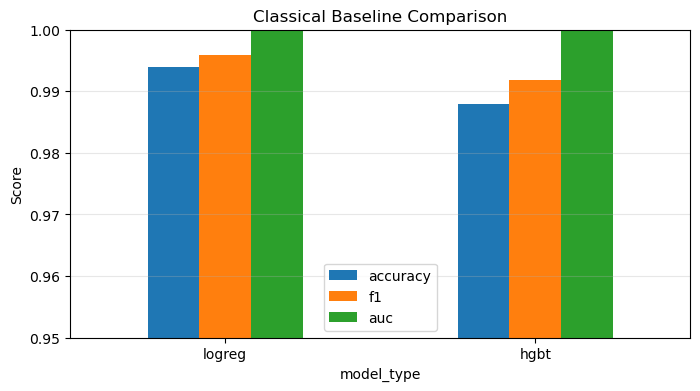

In [24]:
# Compare model metrics visually
plot_df = comparison_df.set_index("model_type")[["accuracy", "f1", "auc"]]
plot_df.plot(kind="bar", figsize=(8, 4), ylim=(0.95, 1.0), rot=0)
plt.title("Classical Baseline Comparison")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [25]:
# Threshold analysis — operational risk trade-off
print("=== Threshold Analysis ===")
print(f"{'Threshold':>10s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'FPR':>10s} {'FNR':>10s}")
print("-" * 60)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    metrics = evaluate_pair_classifier(baseline_model, final_test_pairs, all_records, threshold=threshold)
    print(
        f"{threshold:>10.1f} "
        f"{metrics['precision']:>10.4f} "
        f"{metrics['recall']:>10.4f} "
        f"{metrics['f1']:>10.4f} "
        f"{metrics['fpr']:>10.4f} "
        f"{metrics['fnr']:>10.4f}"
    )


=== Threshold Analysis ===
 Threshold  Precision     Recall         F1        FPR        FNR
------------------------------------------------------------
       0.3     0.9977     0.9982     0.9980     0.0064     0.0018
       0.4     0.9977     0.9973     0.9975     0.0064     0.0027
       0.5     0.9977     0.9968     0.9973     0.0064     0.0032
       0.6     0.9977     0.9968     0.9973     0.0064     0.0032
       0.7     0.9977     0.9964     0.9970     0.0064     0.0036
       0.8     0.9977     0.9964     0.9970     0.0064     0.0036
       0.9     0.9982     0.9923     0.9952     0.0051     0.0077


In [26]:
# Save the selected baseline model
save_pair_classifier(baseline_model, BASELINE_MODEL_PATH)
print(f"Model saved to {BASELINE_MODEL_PATH}")


Model saved to baseline_model.joblib


## 7. Candidate Generation (Blocking Coverage)

For the 1M-record Mecklenburg file, the critical scaling step is **candidate generation**.
We therefore evaluate blocking coverage directly: how many known DPL duplicate pairs are retrieved by the blocking rules before scoring?


In [27]:
def blocking_candidate_recall(records_df, dpl_df, max_block_size=500, max_pairs_per_block=200):
    candidates = set(block_and_generate_candidates(
        records_df,
        max_block_size=max_block_size,
        max_pairs_per_block=max_pairs_per_block,
    ))
    id_to_idx = {str(rid): idx for idx, rid in enumerate(records_df["id"].astype(str))}

    hits = 0
    total = 0
    for row in dpl_df.itertuples(index=False):
        id1, id2 = str(row.id1), str(row.id2)
        if id1 not in id_to_idx or id2 not in id_to_idx:
            continue
        total += 1
        pair = (min(id_to_idx[id1], id_to_idx[id2]), max(id_to_idx[id1], id_to_idx[id2]))
        if pair in candidates:
            hits += 1

    recall = hits / max(total, 1)
    return candidates, {"n_candidates": len(candidates), "n_ground_truth": total, "hits": hits, "recall": recall}


In [28]:
candidate_pairs, blocking_stats = blocking_candidate_recall(df, dpl)
print("=== Blocking Coverage on HPI Dataset ===")
for key, value in blocking_stats.items():
    if key == "recall":
        print(f"  {key:14s}: {value:.4f}")
    else:
        print(f"  {key:14s}: {value:,}")


Blocking: 28,829 blocks, mean size=2.5, max size=23
Candidate pairs from blocking: 34,851
=== Blocking Coverage on HPI Dataset ===
  n_candidates  : 34,851
  n_ground_truth: 9,819
  hits          : 9,791
  recall        : 0.9971


## Summary (Training Pipeline)

This notebook now implements:

1. **Preprocessing**: standardized names, addresses, ZIP codes, and birth years
2. **Silver/Gold labels**: proxy duplicate supervision from exact groups + birth-year validation
3. **Strict entity split**: duplicate-connected components separated across train/test with no record leakage
4. **Split-safe augmentation**: train/test/stress seeds restricted by split IDs
5. **Classical supervised baseline**: field-level similarity features scored by logistic regression or histogram gradient boosting
6. **Scalable inference path**: blocking → pair scoring → clustering

### Deployment recommendation
- Use **logistic regression** as the default production scorer
- Keep **HGBT** as a higher-capacity comparison model
- Treat Mecklenburg-scale duplicate detection as a supervised candidate-scoring problem, not a deep end-to-end embedding problem


## 8. Production Inference — Find Duplicates in New Data

The supervised pipeline above produces a saved model (`baseline_model.joblib`).
The inference path below scores blocked candidate pairs and clusters links above a threshold.

### Pipeline
```
Raw TSV -> Preprocess -> Blocking -> Feature Scoring -> Cluster -> Output
```

**Why this is the recommended production path:**
- avoids the collapsed Siamese encoder entirely
- scales well because logistic regression scoring is cheap
- works for both HPI-format files and statewide NCSBE files such as Mecklenburg's `ncvoter60.txt`


In [29]:
baseline_model = load_pair_classifier(BASELINE_MODEL_PATH)


### 8a. One-command inference on the HPI dataset (quick validation)

This verifies the full blocking + supervised scoring + clustering path end to end on the local HPI-format file.


In [30]:
clusters_df, scored_pairs_df = find_duplicates_with_baseline(
    input_path="ncvoters.tsv",
    model_path=BASELINE_MODEL_PATH,
    output_path="ncvoters_duplicates.tsv",
    threshold=DEPLOYMENT_THRESHOLD,
    max_block_size=500,
    max_pairs_per_block=200,
    score_batch_size=50_000,
)

print()
print("Top 10 highest-confidence duplicate pairs:")
display(scored_pairs_df.head(10))


Blocking: 28,829 blocks, mean size=2.5, max size=23
Candidate pairs from blocking: 34,851

Top 10 highest-confidence duplicate pairs:


,id1,id2,score
0,11947607,12023160,0.999993
1,451887,797378,0.999991
2,557812,797378,0.999991
3,7034622,12113057,0.999988
4,7034622,12023160,0.999987
5,7034622,11947607,0.999987
6,11772613,13995127,0.999977
7,764511,6660590,0.999976
8,1900367,11813479,0.999975
9,6203500,10462671,0.999975


In [31]:
if len(clusters_df) > 0:
    display_fields = [
        "cluster_id", "id", "first_name", "middle_name", "last_name",
        "name_suffix", "street_address", "city", "zip5", "birth_year",
    ]
    available = [field for field in display_fields if field in clusters_df.columns]

    for cluster_id in clusters_df["cluster_id"].unique()[:5]:
        print()
        print(f"--- Cluster {cluster_id} ---")
        display(clusters_df[clusters_df["cluster_id"] == cluster_id][available])
else:
    print("No duplicate clusters found at this threshold.")



--- Cluster 0 ---


,cluster_id,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
0,0,277,DOMENIQUE,ANNA,GRAMOLINI,,1313 ELDORADO ST,BURLINGTON,27217,1987
1,0,9846834,DOMENIQUE,ANNA,GRAMOLINI,,200 CHESHIRE DR 21G,HILLSBOROUGH,27278,1987



--- Cluster 1 ---


,cluster_id,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
2,1,566,DEBORAH,,WELLS,,1908 GLENKIRK DR,BURLINGTON,27215,1969
3,1,13163760,DEBORAH,BESINGER,WELLS,,5715 MAGELLAN WAY 103,RALEIGH,27612,1969



--- Cluster 3 ---


,cluster_id,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
4,3,1567,ALYSSA,DANIELLE,MARION,,852 S SPRING ST,BURLINGTON,27215,1988
5,3,55722,ALYSSA,JACKLYN,FISCHER,,630 N AVE,BURLINGTON,27217,1988
6,3,2580007,ALYSIA,MARIE,PALUMBO,,358 OFFING DR,FAYETTEVILLE,28314,1988
7,3,6276811,ALYSIA,MARIE,PALUMBO,,414 DUNROBIN DR,RAEFORD,28376,1988
8,3,6878664,ALYSSA,JACLYN,FERGUSON,,106 MILL RUN LN,SANFORD,27330,1988
9,3,12323485,ALYSSA,JACLYN,FERGUSON,,408 CLOVER LN G,RALEIGH,27604,1988



--- Cluster 4 ---


,cluster_id,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
10,4,1583,LACOSTA,GAIL,WILLIAMSON,,2248 MAY DR,BURLINGTON,27215,1981
11,4,1723686,LACOSTA,GAIL,WEBSTER,,1650 VANDER OLDHAM RD,BEAR CREEK,27207,1981



--- Cluster 5 ---


,cluster_id,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
12,5,1740,JAKIA,TYKEL,SELLARS,,1120 ELWOOD ST,BURLINGTON,27217,1995
13,5,121402,JAKIA,TYKEL,SELLARS,,1010 FIX ST,BURLINGTON,27215,1995
14,5,1418321,JAKIA,TYKEL,SELLARS,,139 ROGER SELLARS RD,YANCEYVILLE,27379,1995


### 8b. Mecklenburg dataset smoke test and full run

Point `NCVOTER60_PATH` at the extracted `ncvoter60.txt` file.
The cell below does two things:

1. runs a **smoke test** on the first `MECK_SAMPLE_SIZE` rows so you can validate the pipeline quickly
2. optionally runs the **full Mecklenburg file** if `RUN_FULL_MECKLENBURG = True`

The full run can take substantial time depending on the block sizes and available memory.


In [32]:
import pandas as pd
import requests
from pathlib import Path
import zipfile

url = "https://s3.amazonaws.com/dl.ncsbe.gov/data/ncvoter60.zip"
zip_path = Path("ncvoter60.zip")

r = requests.get(url)
zip_path.write_bytes(r.content)

zipfile.is_zipfile(zip_path)
extract_dir = Path("ncvoter60")
extract_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
	z.extractall(extract_dir)

list(extract_dir.iterdir())

#df = pd.read_csv(
#	extract_dir / 'ncvoter60.txt',
#	sep='\t',
#	encoding='latin1',
	# low_memory=False,
#)

[PosixPath('ncvoter60/ncvoter60.txt')]

In [33]:
NCVOTER60_PATH = "ncvoter60/ncvoter60.txt"  # adjust this path
MECK_SAMPLE_SIZE = 100_000
RUN_FULL_MECKLENBURG = True

meck_sample_pairs = pd.DataFrame()
meck_sample_clusters = pd.DataFrame()
meck_full_pairs = pd.DataFrame()
meck_full_clusters = pd.DataFrame()

def read_tsv_with_encoding_fallback(path, **kwargs):
    last_error = None
    for encoding in ("cp1252", "latin-1"):
        try:
            df = pd.read_csv(path, encoding=encoding, **kwargs)
            print(f"Loaded {path} with encoding={encoding}")
            return df
        except UnicodeDecodeError as err:
            last_error = err
    raise last_error


if Path(NCVOTER60_PATH).exists():
    meck_sample_path = Path("ncvoter60_sample.tsv")
    meck_sample_raw = read_tsv_with_encoding_fallback(
        NCVOTER60_PATH,
        sep="\t",
        dtype=str,
        na_filter=False,
        nrows=MECK_SAMPLE_SIZE,
        on_bad_lines="skip",
    )
    meck_sample_raw.to_csv(meck_sample_path, sep="\t", index=False)

    print(f"Running Mecklenburg smoke test on first {MECK_SAMPLE_SIZE:,} rows...")
    meck_sample_clusters, meck_sample_pairs = find_duplicates_with_baseline(
        input_path=meck_sample_path,
        model_path=BASELINE_MODEL_PATH,
        output_path="ncvoter60_sample_duplicates.tsv",
        threshold=DEPLOYMENT_THRESHOLD,
        max_block_size=500,
        max_pairs_per_block=200,
        score_batch_size=50_000,
    )
    display(meck_sample_pairs.head(20))

    if RUN_FULL_MECKLENBURG:
        print()
        print("Running full Mecklenburg inference...")
        meck_full_clusters, meck_full_pairs = find_duplicates_with_baseline(
            input_path=NCVOTER60_PATH,
            model_path=BASELINE_MODEL_PATH,
            output_path="ncvoter60_duplicates.tsv",
            threshold=DEPLOYMENT_THRESHOLD,
            max_block_size=500,
            max_pairs_per_block=200,
            score_batch_size=100_000,
        )
        display(meck_full_pairs.head(20))
    else:
        print()
        print("Skipping full Mecklenburg run. Set RUN_FULL_MECKLENBURG = True to execute it.")
else:
    print(f"File not found: {NCVOTER60_PATH}")
    print("Download from: https://s3.amazonaws.com/dl.ncsbe.gov/data/ncvoter60.zip")
    print("Unzip and update NCVOTER60_PATH above.")


Loaded ncvoter60/ncvoter60.txt with encoding=cp1252
Running Mecklenburg smoke test on first 100,000 rows...
Blocking: 77,055 blocks, mean size=6.3, max size=438
Candidate pairs from blocking: 1,667,216


,id1,id2,score
0,CW503741,CW324825,0.999966
1,BB91451,CW1240964,0.999934
2,CW59038,CW137716,0.999918
3,CW300798,CW293431,0.999910
4,CW1556508,CW1145416,0.999908
5,CW44221,CW67499,0.999898
6,CW460242,BR243235,0.999896
7,CW750451,CW388776,0.999889
8,CW5074,CW55395,0.999879
9,CW223518,CW68189,0.999877



Running full Mecklenburg inference...
Blocking: 730,481 blocks, mean size=7.2, max size=495
Candidate pairs from blocking: 16,342,659


,id1,id2,score
0,CW1466892,CW1306404,0.999992
1,CW1237043,CW1056266,0.999990
2,CW1237129,CW83315,0.999990
3,CW1110029,CW1328188,0.999990
4,CW1302824,CW500419,0.999989
5,CW1139602,CW1402698,0.999982
6,CW770611,CW1287889,0.999981
7,CW860866,CW786158,0.999974
8,CW1572941,CW1605460,0.999969
9,CW1329441,CW1316646,0.999969


In [34]:
meck_cluster_label = None
meck_cluster_view = pd.DataFrame()

if len(meck_full_clusters) > 0:
    meck_cluster_label = "Full Mecklenburg"
    meck_cluster_view = meck_full_clusters
elif len(meck_sample_clusters) > 0:
    meck_cluster_label = "Sample Mecklenburg"
    meck_cluster_view = meck_sample_clusters

if len(meck_cluster_view) > 0:
    display_fields = [
        "cluster_id", "id", "first_name", "middle_name", "last_name",
        "name_suffix", "street_address", "city", "zip5", "birth_year",
    ]
    available = [field for field in display_fields if field in meck_cluster_view.columns]

    print(f"=== {meck_cluster_label} clusters ===")
    for cluster_id in meck_cluster_view["cluster_id"].unique()[:10]:
        print()
        print(f"--- Cluster {cluster_id} ---")
        display(meck_cluster_view[meck_cluster_view["cluster_id"] == cluster_id][available])
else:
    print("No Mecklenburg clusters available yet. Run the smoke test or full Mecklenburg cell first.")


=== Full Mecklenburg clusters ===

--- Cluster 1 ---


,cluster_id,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
0,1,CW1170669,CHUA,,A,,10627 ELM BEND DR,CHARLOTTE,28273,1993
1,1,DZ62945,CHUEYIM,,VANG,,REMOVED,,,1993



--- Cluster 40782 ---


,cluster_id,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
2,40782,CW1164524,HAI,,A,,1927 O HARA DR,CHARLOTTE,28273,1983
3,40782,CW1566669,LAM,,A,,12321 CHARING GROVE LN,CHARLOTTE,28273,1988
4,40782,CW1286023,LANG,LANG,A,,4738 CARRIAGE DR CIR 3,CHARLOTTE,28205,1989
5,40782,CW1365848,THAI,,A,,10627 ELM BEND DR,CHARLOTTE,28273,1984
6,40782,CW621562,THEK,,A,,12007 SWANEE LN,CHARLOTTE,28273,1952
...,...,...,...,...,...,...,...,...,...,...
768775,40782,CW1335416,MONICA,DEBRA,ZYWCZYK,,5821 HANNA CT,CHARLOTTE,28212,1991
768776,40782,CW1546413,CORY,JAMES,ZYWICKI,,15933 ARABIAN MEWS LN,CHARLOTTE,28278,1963
768777,40782,CW1528503,DANIEL,,ZYWICKI,,19516 KISTLER FARM RD,DAVIDSON,28036,1975
768778,40782,CW1484561,ZACHARY,KNUTE,ZYWNA,,642 W END DR,CHARLOTTE,28208,1999



--- Cluster 4 ---


...

,cluster_id,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
780212,48,CW587793,CLIFFORD,SCOTT,AARON,,8300 FOX CHAPEL LN 538,CHARLOTTE,28270,1974
780213,48,CW1023579,CLIFFORD,JAMES,KENYON,JR,316 MCDONALD AVE,CHARLOTTE,28203,1974
780214,48,CW375840,CLIFFORD,WEBSTER,PERRY,III,REMOVED,,,1974
780215,48,CW868623,CLIFFORD,PERKINS,TUCKER,III,258 ENWOOD DR,CHARLOTTE,28214,1974
780216,48,EF38306,CLIFFORD,JEROME,WHITE,,10024 PERGOLA VIEW CT,CHARLOTTE,28213,1974



--- Cluster 55 ---


,cluster_id,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
780217,55,CW752023,ESTELLE,,AARON,,REMOVED,,,1929
780218,55,CW2959,ESTELLE,H,AUSTIN,,REMOVED,,,1929
780219,55,CW7923,ESTHER,J,COBB,,REMOVED,,,1929



--- Cluster 63 ---


,cluster_id,id,first_name,middle_name,last_name,name_suffix,street_address,city,zip5,birth_year
780220,63,CW37446,IRENE,DEATON,AARON,,REMOVED,,,1921
780221,63,CW724312,IRENE,DUCKETT,ROCKETT,,REMOVED,,,1921


### 8c. Single-record lookup with the baseline scorer

For a single query, we append the query record to the normalized Mecklenburg record table,
collect candidate pairs that involve the query via blocking, and then score only those pairs.
The query is a real record sampled from the Mecklenburg dataset so we can validate that the
model correctly identifies it (and any true duplicates) in the unseen data.

In [35]:
def find_matches_for_query(query_record, records_df, bundle, threshold=0.3, top_k=20, max_block_size=500):
    standardized_query = {
        "id": "__query__",
        "first_name": normalize_name(query_record.get("first_name", "")),
        "middle_name": normalize_name(query_record.get("middle_name", "")),
        "last_name": normalize_name(query_record.get("last_name", "")),
        "name_suffix": normalize_suffix(query_record.get("name_suffix", "")),
        "street_address": normalize_single_street_address(query_record.get("street_address", "")),
        "city": normalize_name(query_record.get("city", "")),
        "zip5": normalize_zip5(query_record.get("zip5", "")),
        "birth_year": str(query_record.get("birth_year", "")).strip(),
    }
    query_df = pd.DataFrame([standardized_query])

    combined = pd.concat([records_df, query_df], ignore_index=True)
    block_index = build_block_index(combined, max_block_size=max_block_size)
    query_idx = len(combined) - 1

    candidate_pairs = sorted(
        {
            (min(idx, query_idx), max(idx, query_idx))
            for members in block_index.values()
            if query_idx in members
            for idx in members
            if idx != query_idx
        }
    )

    if not candidate_pairs:
        return pd.DataFrame(columns=["id", "score"])

    scores = score_candidate_pairs(bundle, candidate_pairs, combined, batch_size=10_000)
    rows = []
    for (left, right), score in zip(candidate_pairs, scores):
        if score >= threshold:
            row_idx = left if right == query_idx else right
            row = combined.iloc[row_idx].to_dict()
            row["score"] = float(score)
            rows.append(row)

    results = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    return results.head(top_k)

# --- Pick a real record from the Mecklenburg dataset as the query ---
# Instead of a fabricated person, sample a real record from the Mecklenburg
# dataset and look up its matches.  This validates that the model finds the
# record itself (score ~1.0) and any true duplicates nearby.
def _load_meck_lookup_records(path):
    raw = read_tsv_with_encoding_fallback(
        path,
        sep="\t",
        dtype=str,
        na_filter=False,
        on_bad_lines="skip",
    )
    return normalize_dataframe(raw)

lookup_records = df.copy()
lookup_label = "training dataframe"

if len(meck_full_pairs) > 0 and Path(NCVOTER60_PATH).exists():
    if "meck_full_records" not in globals():
        meck_full_records = _load_meck_lookup_records(NCVOTER60_PATH)
    lookup_records = meck_full_records
    lookup_label = "full Mecklenburg"
elif len(meck_sample_pairs) > 0 and Path("ncvoter60_sample.tsv").exists():
    if "meck_sample_records" not in globals():
        meck_sample_records = _load_meck_lookup_records("ncvoter60_sample.tsv")
    lookup_records = meck_sample_records
    lookup_label = "sample Mecklenburg"

# Use a real record from the lookup dataset as the query
sample_row = lookup_records.iloc[0]
query = {
    "first_name": sample_row.get("first_name", ""),
    "middle_name": sample_row.get("middle_name", ""),
    "last_name": sample_row.get("last_name", ""),
    "name_suffix": sample_row.get("name_suffix", ""),
    "street_address": sample_row.get("street_address", ""),
    "city": sample_row.get("city", ""),
    "zip5": sample_row.get("zip5", ""),
    "birth_year": str(sample_row.get("birth_year", "")),
}

query_results = find_matches_for_query(
    query_record=query,
    records_df=lookup_records,
    bundle=baseline_model,
    threshold=0.3,
    top_k=20,
)

print(f"Lookup source: {lookup_label}")
print(f"Query: {query['first_name']} {query['last_name']}, {query['street_address']}")
print(f"Found {len(query_results)} candidate matches:")
if len(query_results) > 0:
    display_cols = [col for col in ["id", "first_name", "last_name", "street_address", "city", "zip5", "birth_year", "score"] if col in query_results.columns]
    display(query_results[display_cols])
else:
    print("  No matches found above threshold.")

Loaded ncvoter60/ncvoter60.txt with encoding=cp1252
Lookup source: full Mecklenburg
Query: CARMEN A, 2405 WOODEN PEG CT
Found 20 candidate matches:


,id,first_name,last_name,street_address,city,zip5,birth_year,score
0,CW1441960,CARMEN,A,2405 WOODEN PEG CT,CHARLOTTE,28273,2003,0.999993
1,CW1394763,CARMEN,LOLLA,12228 NOTCHWOOD CT,HUNTERSVILLE,28078,2003,0.999540
2,CW1397369,CARMEN,COUSART,10301 PLUM CREEK LN H,CHARLOTTE,28210,2003,0.999407
3,BN556362,CARMEN,MCKEE,6030 HARKEY RD 8202,MATTHEWS,28105,2003,0.998947
4,CW1447535,CARMEN,MEADE,9525 PUDDLE DUCK RD 202,CHARLOTTE,28262,2003,0.998785
5,CW1452299,CARMEN,DESOUZA,4205 BURNING TREE DR,CHARLOTTE,28277,2003,0.998775
6,CW1394840,CARMEN,SOWERS,10302 LEGOLAS LN,CHARLOTTE,28269,2003,0.998724
7,CW1407836,CARMEN,ROBINSON,1356 WATERLILY LN,CHARLOTTE,28262,2003,0.998499
8,CW1408117,CARMEN,DUNN,10621 MIDWAY PARK DR 14006,CHARLOTTE,28277,2003,0.998267
9,AE37530,CARMEN,MCKEE,444 WALDEN STATION DR 02,CHARLOTTE,28262,2003,0.998173


### 8d. Threshold sensitivity analysis

This shows how many scored links survive as the threshold changes. It is useful for choosing an operating point before clustering the full Mecklenburg file.


In [36]:
sensitivity_pairs = pd.DataFrame()
sensitivity_label = None

if len(meck_full_pairs) > 0:
    sensitivity_pairs = meck_full_pairs
    sensitivity_label = "full Mecklenburg"
elif len(meck_sample_pairs) > 0:
    sensitivity_pairs = meck_sample_pairs
    sensitivity_label = "sample Mecklenburg"
elif len(scored_pairs_df) > 0:
    sensitivity_pairs = scored_pairs_df
    sensitivity_label = "baseline inference demo"

if len(sensitivity_pairs) > 0:
    print(f"Threshold sensitivity for {sensitivity_label}:")
    print(f"{'Threshold':>10s} {'Pairs':>10s} {'Records in pairs':>20s}")
    print("-" * 46)

    for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
        above = sensitivity_pairs[sensitivity_pairs["score"] >= threshold]
        n_pairs = len(above)
        n_records = len(set(above["id1"].tolist() + above["id2"].tolist())) if n_pairs else 0
        print(f"{threshold:>10.1f} {n_pairs:>10,} {n_records:>20,}")
else:
    print("No scored pairs available. Run the Mecklenburg or baseline inference cell first.")


Threshold sensitivity for full Mecklenburg:
 Threshold      Pairs     Records in pairs
----------------------------------------------
       0.3  2,263,029              842,626
       0.4  2,263,029              842,626
       0.5  2,263,029              842,626
       0.6  2,033,680              809,186
       0.7  1,814,653              769,699
       0.8  1,563,298              717,372
       0.9  1,160,335              624,918


In [43]:
# Show logistic regression coefficients aligned with feature names
model = None
if "baseline_model" in globals() and hasattr(baseline_model, "model"):
    model = baseline_model.model
elif "bundle" in globals() and hasattr(bundle, "model"):
    model = bundle.model

if model is not None and hasattr(model, "named_steps") and "classifier" in model.named_steps:
    classifier = model.named_steps["classifier"]

feature_names = None
if "baseline_model" in globals() and hasattr(baseline_model, "feature_columns"):
    feature_names = baseline_model.feature_columns
elif "bundle" in globals() and hasattr(bundle, "feature_columns"):
    feature_names = bundle.feature_columns

if "classifier" in globals() and hasattr(classifier, "coef_"):
    if feature_names:
        coef_df = pd.DataFrame({
            "feature": feature_names,
            "coefficient": classifier.coef_[0],
        })
        coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
        display(coef_df.sort_values("abs_coefficient", ascending=False))
    else:
        print("Coefficients:")
        print(classifier.coef_[0])
else:
    print("No logistic regression coefficients found in the current kernel.")


,feature,coefficient,abs_coefficient
3,full_name_ratio,4.147535,4.147535
11,birth_year_eq,3.902380,3.902380
0,first_name_ratio,2.111719,2.111719
7,full_record_ratio,1.859466,1.859466
10,house_number_eq,1.080840,1.080840
2,last_name_ratio,-1.008094,1.008094
12,birth_year_absdiff,-0.919435,0.919435
1,middle_name_ratio,-0.883672,0.883672
6,city_ratio,-0.800709,0.800709
9,zip5_eq,-0.731366,0.731366


## 9. Deep Learning: Train Siamese Matching Network

We train the character-level CNN Siamese network using the same entity-level
split and augmented pairs prepared above. The model architecture (CharCNNEncoder
+ MLP comparison head) is defined in `src/model.py`. Training uses
BCEWithLogitsLoss with label smoothing and ReduceLROnPlateau scheduling.

This complements the classical LogReg baseline with a learned representation
that can also produce record embeddings for ANN-based candidate retrieval.

In [38]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.model import SiameseMatchingNetwork
from src.dataset import RecordPairDataset
from src.train import train_model, evaluate

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Training device: {device}")

Training device: mps


In [42]:
# Build datasets using the same pairs and records as the classical baseline
train_dataset = RecordPairDataset(
    pairs_df=final_train_pairs,
    records_df=all_records,
    max_len=128,
)

test_dataset = RecordPairDataset(
    pairs_df=final_test_pairs,
    records_df=all_records,
    char_vocab=train_dataset.char_vocab,  # share vocab
    max_len=128,
)

print(f"Vocab size: {train_dataset.vocab_size}")
print(f"Train samples: {len(train_dataset):,}")
print(f"Test samples:  {len(test_dataset):,}")

# Save vocab for later use in inference
char_vocab = train_dataset.char_vocab

Vocab size: 42
Train samples: 28,381
Test samples:  2,985


In [46]:
BATCH_SIZE = 256
N_EPOCHS = 30
LEARNING_RATE = 1e-3

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)

siamese_model = SiameseMatchingNetwork(
    vocab_size=train_dataset.vocab_size,
    embed_dim=32,
    num_filters=128,
    kernel_sizes=(3, 4, 5),
    encoder_output_dim=128,
    classifier_hidden_dim=64,
    dropout=0.3,
)

total_params = sum(p.numel() for p in siamese_model.parameters())
trainable_params = sum(p.numel() for p in siamese_model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,} total, {trainable_params:,} trainable")

Model parameters: 119,041 total, 119,041 trainable


In [47]:
# --- Diagnostic: verify data pipeline before training ---
import importlib, src.model, src.train
importlib.reload(src.model); importlib.reload(src.train)
from src.model import SiameseMatchingNetwork
from src.train import train_model

sample = train_dataset[0]
n_nonpad_1 = (sample["input1"] != 0).sum().item()
n_nonpad_2 = (sample["input2"] != 0).sum().item()
print(f"Sample 0: input1 has {n_nonpad_1} non-pad chars, input2 has {n_nonpad_2} non-pad chars, label={sample['label'].item()}")

# Check how many record lookups succeed
n_miss = 0
for i in range(min(500, len(train_dataset.pairs))):
    row = train_dataset.pairs.iloc[i]
    if str(row["id1"]) not in train_dataset.records.index:
        n_miss += 1
    if str(row["id2"]) not in train_dataset.records.index:
        n_miss += 1
print(f"Record lookup misses in first 500 pairs: {n_miss} / {1000}")

# Check a quick forward pass produces varied outputs
tmp_model = SiameseMatchingNetwork(vocab_size=train_dataset.vocab_size, embed_dim=32, num_filters=128,
                                   kernel_sizes=(3,4,5), encoder_output_dim=128, classifier_hidden_dim=64, dropout=0.0)
tmp_model.eval()
batch = next(iter(train_loader))
with torch.no_grad():
    logits = tmp_model(batch["input1"], batch["input2"])
    probs = torch.sigmoid(logits).squeeze()
print(f"Fresh model output range: [{probs.min():.4f}, {probs.max():.4f}], std={probs.std():.4f}")
print(f"  (should show varied outputs, not constant)")
del tmp_model

Sample 0: input1 has 71 non-pad chars, input2 has 71 non-pad chars, label=1.0
Record lookup misses in first 500 pairs: 0 / 1000
Fresh model output range: [0.3105, 0.6115], std=0.0520
  (should show varied outputs, not constant)


In [48]:
# Re-instantiate model (fresh weights) before training
siamese_model = SiameseMatchingNetwork(
    vocab_size=train_dataset.vocab_size,
    embed_dim=32,
    num_filters=128,
    kernel_sizes=(3, 4, 5),
    encoder_output_dim=128,
    classifier_hidden_dim=64,
    dropout=0.3,
)

history = train_model(
    model=siamese_model,
    train_loader=train_loader,
    val_loader=test_loader,
    device=device,
    n_epochs=N_EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=1e-4,
    patience=7,
)

Class distribution: 11183 pos, 17198 neg (ratio=1.54)
Epoch   1/30 | Train Loss: 0.6866 | Val Loss: 0.8049 | Val F1: 0.0000 | Val AUC: 0.6097 | LR: 0.001000
Epoch   2/30 | Train Loss: 0.6718 | Val Loss: 0.7906 | Val F1: 0.0000 | Val AUC: 0.6080 | LR: 0.001000
Epoch   3/30 | Train Loss: 0.6688 | Val Loss: 0.7714 | Val F1: 0.0000 | Val AUC: 0.6067 | LR: 0.001000
Epoch   4/30 | Train Loss: 0.6713 | Val Loss: 0.8256 | Val F1: 0.0000 | Val AUC: 0.6173 | LR: 0.001000
Epoch   5/30 | Train Loss: 0.6687 | Val Loss: 0.7279 | Val F1: 0.0947 | Val AUC: 0.6272 | LR: 0.001000
Epoch   6/30 | Train Loss: 0.6644 | Val Loss: 0.7830 | Val F1: 0.0000 | Val AUC: 0.6437 | LR: 0.001000
Epoch   7/30 | Train Loss: 0.6530 | Val Loss: 0.6991 | Val F1: 0.0000 | Val AUC: 0.7196 | LR: 0.001000
Epoch   8/30 | Train Loss: 0.5404 | Val Loss: 0.4485 | Val F1: 0.9085 | Val AUC: 0.8844 | LR: 0.001000
Epoch   9/30 | Train Loss: 0.4146 | Val Loss: 0.2160 | Val F1: 0.9407 | Val AUC: 0.9608 | LR: 0.001000
Epoch  10/30 | Trai

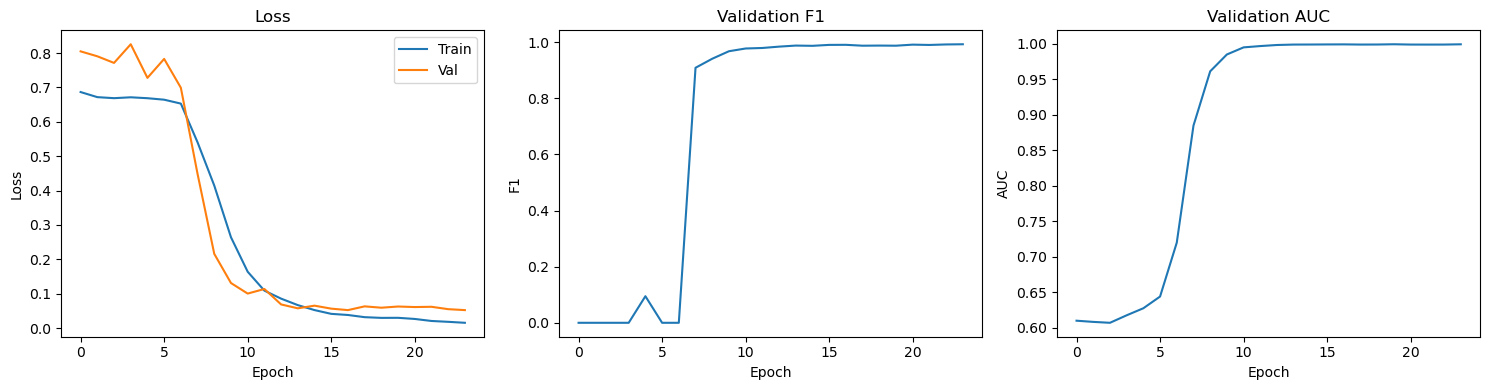

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_f1"])
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")
axes[1].set_title("Validation F1")

axes[2].plot(history["val_auc"])
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")
axes[2].set_title("Validation AUC")

plt.tight_layout()
plt.show()

In [50]:
# Evaluate Siamese on test set and compare with LogReg
criterion = nn.BCEWithLogitsLoss()
siamese_metrics = evaluate(siamese_model, test_loader, criterion, device)

print("=== Siamese Model Test Metrics ===")
for key, value in siamese_metrics.items():
    print(f"  {key:10s}: {value:.4f}")

# Compare with classical baseline
print("\n=== Comparison: LogReg vs Siamese ===")
print(f"{'Metric':<12s} {'LogReg':>10s} {'Siamese':>10s}")
print("-" * 34)

logreg_metrics = evaluate_pair_classifier(
    baseline_model, final_test_pairs, all_records, threshold=DEPLOYMENT_THRESHOLD,
)
for key in ["accuracy", "precision", "recall", "f1", "auc"]:
    lr_val = logreg_metrics.get(key, 0)
    si_val = siamese_metrics.get(key, 0)
    print(f"{key:<12s} {lr_val:>10.4f} {si_val:>10.4f}")

=== Siamese Model Test Metrics ===
  loss      : 0.0524
  accuracy  : 0.9856
  precision : 0.9817
  recall    : 0.9991
  f1        : 0.9903
  auc       : 0.9988
  fpr       : 0.0522
  fnr       : 0.0009

=== Comparison: LogReg vs Siamese ===
Metric           LogReg    Siamese
----------------------------------
accuracy         0.9960     0.9856
precision        0.9977     0.9817
recall           0.9968     0.9991
f1               0.9973     0.9903
auc              0.9997     0.9988


In [51]:
SIAMESE_MODEL_PATH = "siamese_model.pt"

checkpoint = {
    "model_state_dict": siamese_model.state_dict(),
    "char_vocab": char_vocab,
    "vocab_size": train_dataset.vocab_size,
    "history": history,
}
torch.save(checkpoint, SIAMESE_MODEL_PATH)
print(f"Siamese model saved to {SIAMESE_MODEL_PATH}")

Siamese model saved to siamese_model.pt


## 10. ANN-Based Candidate Retrieval

Using the trained Siamese encoder, we embed all HPI records into a 128-d vector
space and build a FAISS index for approximate nearest-neighbor search. This
produces a complementary candidate set to rule-based blocking.

The key insight: ANN retrieval catches semantically similar records that may not
share exact blocking key components (e.g., name misspellings + address changes
simultaneously), while rule-based blocking catches records that are hard to embed
well (e.g., very short names).

In [53]:
from src.inference import batch_embed_records, build_faiss_index, ann_search

# Embed all original HPI records (NOT augmented -- inference is on real data)
embeddings = batch_embed_records(
    model=siamese_model,
    records_df=df,
    char_vocab=char_vocab,
    device=device,
    batch_size=512,
    max_len=128,
)
print(f"Embeddings shape: {embeddings.shape}")

# Build FAISS index
faiss_index = build_faiss_index(embeddings, use_gpu=False)
print(f"FAISS index built: {type(faiss_index).__name__}")

Embeddings shape: (14183, 128)
FAISS index built: IndexFlatIP


In [ ]:
ANN_K = 20  # top-K neighbors per record

distances, indices = ann_search(faiss_index, embeddings, k=ANN_K, batch_size=4096)

# Convert ANN results to candidate pairs
ann_candidate_set = set()
for i in range(len(df)):
    for j_pos in range(ANN_K):
        j = int(indices[i, j_pos])
        if j != i and j >= 0:
            ann_candidate_set.add((min(i, j), max(i, j)))

print(f"ANN candidate pairs: {len(ann_candidate_set):,}")

In [ ]:
# Evaluate ANN blocking recall against DPL ground truth
id_to_idx = {str(rid): idx for idx, rid in enumerate(df["id"].astype(str))}

ann_hits = 0
ann_total = 0
for row in dpl.itertuples(index=False):
    id1, id2 = str(row.id1), str(row.id2)
    if id1 not in id_to_idx or id2 not in id_to_idx:
        continue
    ann_total += 1
    pair = (min(id_to_idx[id1], id_to_idx[id2]), max(id_to_idx[id1], id_to_idx[id2]))
    if pair in ann_candidate_set:
        ann_hits += 1

ann_recall = ann_hits / max(ann_total, 1)
print(f"ANN blocking recall: {ann_recall:.4f} ({ann_hits:,}/{ann_total:,})")

In [ ]:
# Evaluate improved rule-based blocking recall (with the 3 new keys from Step 1)
# The src/blocking module has been updated with 8 keys total
import importlib
import src.blocking
importlib.reload(src.blocking)
from src.blocking import block_and_generate_candidates

improved_candidates = set(block_and_generate_candidates(
    df, max_block_size=500, max_pairs_per_block=200,
))

improved_hits = 0
improved_total = 0
for row in dpl.itertuples(index=False):
    id1, id2 = str(row.id1), str(row.id2)
    if id1 not in id_to_idx or id2 not in id_to_idx:
        continue
    improved_total += 1
    pair = (min(id_to_idx[id1], id_to_idx[id2]), max(id_to_idx[id1], id_to_idx[id2]))
    if pair in improved_candidates:
        improved_hits += 1

improved_recall = improved_hits / max(improved_total, 1)
print(f"Improved rule-based blocking recall: {improved_recall:.4f} ({improved_hits:,}/{improved_total:,})")

In [ ]:
# Union: rule-based + ANN candidates
hybrid_candidate_set = improved_candidates | ann_candidate_set

hybrid_hits = 0
for row in dpl.itertuples(index=False):
    id1, id2 = str(row.id1), str(row.id2)
    if id1 not in id_to_idx or id2 not in id_to_idx:
        continue
    pair = (min(id_to_idx[id1], id_to_idx[id2]), max(id_to_idx[id1], id_to_idx[id2]))
    if pair in hybrid_candidate_set:
        hybrid_hits += 1

hybrid_recall = hybrid_hits / max(ann_total, 1)

print("=== Blocking Recall Comparison ===")
print(f"  Original  (5 keys):  {blocking_stats['recall']:.4f}  ({blocking_stats['hits']:,} / {blocking_stats['n_ground_truth']:,})")
print(f"  Improved  (8 keys):  {improved_recall:.4f}  ({improved_hits:,} / {improved_total:,})")
print(f"  ANN only (k={ANN_K}):     {ann_recall:.4f}  ({ann_hits:,} / {ann_total:,})")
print(f"  Hybrid (rules+ANN): {hybrid_recall:.4f}  ({hybrid_hits:,} / {ann_total:,})")
print()
print("  Candidate counts:")
print(f"    Original (5 keys):     {blocking_stats['n_candidates']:,}")
print(f"    Improved (8 keys):     {len(improved_candidates):,}")
print(f"    ANN only:              {len(ann_candidate_set):,}")
print(f"    Hybrid union:          {len(hybrid_candidate_set):,}")

## 11. Hybrid Pipeline: Combined Blocking + Dual Scoring

The hybrid pipeline unions rule-based and ANN candidates, then scores each
candidate pair with BOTH the classical LogReg and the Siamese network. We
compare three scoring strategies:
1. **LogReg only** — fast, interpretable, hand-crafted features
2. **Siamese only** — learned character-level representations
3. **Ensemble** — weighted average (0.6 LogReg + 0.4 Siamese)

In [ ]:
from src.inference import score_candidate_pairs as siamese_score_pairs
from src.baseline import score_candidate_pairs as baseline_score_pairs

hybrid_candidate_list = sorted(hybrid_candidate_set)
print(f"Scoring {len(hybrid_candidate_list):,} hybrid candidate pairs...")

# Score with LogReg
logreg_scores = baseline_score_pairs(
    baseline_model, hybrid_candidate_list, df, batch_size=50_000,
)

# Score with Siamese
siamese_scores = siamese_score_pairs(
    siamese_model, hybrid_candidate_list, df, char_vocab, device, batch_size=512,
)

print(f"LogReg scores:  min={logreg_scores.min():.4f}, max={logreg_scores.max():.4f}, mean={logreg_scores.mean():.4f}")
print(f"Siamese scores: min={siamese_scores.min():.4f}, max={siamese_scores.max():.4f}, mean={siamese_scores.mean():.4f}")

In [ ]:
from src.baseline import cluster_pairs as baseline_cluster_pairs

# Ensemble: weighted average
LOGREG_WEIGHT = 0.6
SIAMESE_WEIGHT = 0.4
ensemble_scores = LOGREG_WEIGHT * logreg_scores + SIAMESE_WEIGHT * siamese_scores


def evaluate_pipeline(scores, candidates, records_df, dpl_df, threshold=0.5, label=""):
    """Evaluate end-to-end pipeline: candidates + scoring + clustering vs DPL ground truth."""
    clusters = baseline_cluster_pairs(
        candidates, scores, len(records_df),
        threshold=threshold, records_df=records_df,
    )

    # Convert cluster members to pairs for evaluation
    predicted_pairs = set()
    for members in clusters.values():
        for i in range(len(members)):
            for j in range(i + 1, len(members)):
                predicted_pairs.add((min(members[i], members[j]), max(members[i], members[j])))

    # Compare against DPL ground truth
    id_to_idx_local = {str(rid): idx for idx, rid in enumerate(records_df["id"].astype(str))}
    gt_pairs = set()
    for row in dpl_df.itertuples(index=False):
        id1, id2 = str(row.id1), str(row.id2)
        if id1 in id_to_idx_local and id2 in id_to_idx_local:
            a, b = id_to_idx_local[id1], id_to_idx_local[id2]
            gt_pairs.add((min(a, b), max(a, b)))

    tp = len(predicted_pairs & gt_pairs)
    fp = len(predicted_pairs - gt_pairs)
    fn = len(gt_pairs - predicted_pairs)

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)

    print(f"  {label}")
    print(f"    Clusters: {len(clusters):,}")
    print(f"    Predicted pairs: {len(predicted_pairs):,}")
    print(f"    TP={tp:,}  FP={fp:,}  FN={fn:,}")
    print(f"    Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")

    return {"precision": precision, "recall": recall, "f1": f1,
            "tp": tp, "fp": fp, "fn": fn, "n_clusters": len(clusters)}


THRESHOLD = 0.5

print("=== End-to-End Pipeline Evaluation (Hybrid Candidates) ===\n")
logreg_results = evaluate_pipeline(
    logreg_scores, hybrid_candidate_list, df, dpl, threshold=THRESHOLD, label="LogReg only",
)
print()
siamese_results = evaluate_pipeline(
    siamese_scores, hybrid_candidate_list, df, dpl, threshold=THRESHOLD, label="Siamese only",
)
print()
ensemble_results = evaluate_pipeline(
    ensemble_scores, hybrid_candidate_list, df, dpl, threshold=THRESHOLD,
    label=f"Ensemble ({LOGREG_WEIGHT:.1f}*LR + {SIAMESE_WEIGHT:.1f}*Si)",
)

In [ ]:
# Compare with the original baseline pipeline (5 keys + LogReg only)
from src.blocking import block_and_generate_candidates as _bgen

original_5key_candidates = set(candidate_pairs)  # from cell 34 (blocking_candidate_recall)
original_candidate_list = sorted(original_5key_candidates)
original_scores = baseline_score_pairs(
    baseline_model, original_candidate_list, df, batch_size=50_000,
)

print("=== Original Baseline (5 keys + LogReg) ===")
original_results = evaluate_pipeline(
    original_scores, original_candidate_list, df, dpl,
    threshold=THRESHOLD, label="Original baseline",
)

print("\n" + "=" * 72)
print("SUMMARY TABLE")
print("=" * 72)
print(f"{'Pipeline':<45s} {'P':>8s} {'R':>8s} {'F1':>8s} {'Clusters':>10s}")
print("-" * 75)
for name, r in [
    ("Original (5 keys + LogReg)", original_results),
    ("Hybrid cands + LogReg", logreg_results),
    ("Hybrid cands + Siamese", siamese_results),
    ("Hybrid cands + Ensemble", ensemble_results),
]:
    print(f"{name:<45s} {r['precision']:>8.4f} {r['recall']:>8.4f} {r['f1']:>8.4f} {r['n_clusters']:>10,}")

In [ ]:
def find_duplicates_hybrid(
    input_path,
    baseline_model_path,
    siamese_model_path,
    output_path=None,
    threshold=0.5,
    ann_k=20,
    max_block_size=500,
    max_pairs_per_block=200,
    logreg_weight=0.6,
    siamese_weight=0.4,
    score_batch_size=50_000,
):
    """
    Full hybrid duplicate detection pipeline.

    Combines improved rule-based blocking + ANN retrieval,
    then scores with ensemble of LogReg + Siamese.

    Returns:
        (clusters_df, scored_pairs_df)
    """
    import time
    from src.preprocessing import normalize_dataframe
    from src.baseline import (
        load_pair_classifier,
        score_candidate_pairs as _baseline_score,
        cluster_pairs as _baseline_cluster,
        _read_csv_with_encoding_fallback,
    )
    from src.inference import (
        batch_embed_records as _embed,
        build_faiss_index as _build_idx,
        ann_search as _ann,
        score_candidate_pairs as _siamese_score,
    )
    from src.blocking import block_and_generate_candidates as _block
    from src.model import SiameseMatchingNetwork

    _device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "mps" if torch.backends.mps.is_available()
        else "cpu"
    )

    t0 = time.time()

    # 1. Load and preprocess
    print("Step 1: Loading & preprocessing...")
    sep = "\t" if str(input_path).endswith((".tsv", ".txt")) else ","
    raw = _read_csv_with_encoding_fallback(input_path, sep=sep, dtype=str, na_filter=False, on_bad_lines="skip")
    raw = raw.loc[:, ~raw.columns.str.contains(r"^Unnamed")]
    raw.columns = [c.strip().lower() for c in raw.columns]
    records = normalize_dataframe(raw)
    print(f"  Records: {len(records):,}")

    # 2. Load models
    print("Step 2: Loading models...")
    bundle = load_pair_classifier(baseline_model_path)

    ckpt = torch.load(siamese_model_path, map_location=_device, weights_only=False)
    _cv = ckpt["char_vocab"]
    _vs = len(_cv)
    _siamese = SiameseMatchingNetwork(vocab_size=_vs)
    _siamese.load_state_dict(ckpt["model_state_dict"])
    _siamese = _siamese.to(_device).eval()
    print(f"  LogReg + Siamese loaded on {_device}")

    # 3. Candidate generation: rules + ANN
    print("Step 3: Generating candidates...")
    rule_candidates = set(_block(records, max_block_size=max_block_size, max_pairs_per_block=max_pairs_per_block))

    embs = _embed(_siamese, records, _cv, _device, batch_size=512)
    idx = _build_idx(embs)
    _D, _I = _ann(idx, embs, k=ann_k, batch_size=4096)

    ann_cands = set()
    for i in range(len(records)):
        for j_pos in range(ann_k):
            j = int(_I[i, j_pos])
            if j != i and j >= 0:
                ann_cands.add((min(i, j), max(i, j)))

    all_candidates = sorted(rule_candidates | ann_cands)
    print(f"  Rules: {len(rule_candidates):,} | ANN: {len(ann_cands):,} | Union: {len(all_candidates):,}")

    # 4. Dual scoring + ensemble
    print(f"Step 4: Scoring {len(all_candidates):,} pairs...")
    lr_scores = _baseline_score(bundle, all_candidates, records, batch_size=score_batch_size)
    si_scores = _siamese_score(_siamese, all_candidates, records, _cv, _device, batch_size=512)
    final_scores = logreg_weight * lr_scores + siamese_weight * si_scores

    # 5. Cluster
    print("Step 5: Clustering...")
    clusters = _baseline_cluster(
        all_candidates, final_scores, len(records),
        threshold=threshold, records_df=records,
    )
    print(f"  Clusters: {len(clusters):,}")

    # 6. Format output
    cluster_rows = []
    for cid, members in clusters.items():
        for row_idx in members:
            row = records.iloc[row_idx].to_dict()
            row["cluster_id"] = cid
            cluster_rows.append(row)
    clusters_df = pd.DataFrame(cluster_rows) if cluster_rows else pd.DataFrame(
        columns=list(records.columns) + ["cluster_id"]
    )

    pair_rows = []
    for (i, j), score in zip(all_candidates, final_scores):
        if score >= threshold:
            pair_rows.append({
                "id1": str(records.iloc[i]["id"]),
                "id2": str(records.iloc[j]["id"]),
                "score": float(score),
            })
    scored_pairs_df = pd.DataFrame(pair_rows) if pair_rows else pd.DataFrame(columns=["id1", "id2", "score"])
    scored_pairs_df = scored_pairs_df.sort_values("score", ascending=False).reset_index(drop=True)

    if output_path:
        scored_pairs_df.to_csv(output_path, sep="\t", index=False)

    elapsed = time.time() - t0
    print(f"\nDone in {elapsed:.1f}s  |  {len(clusters):,} clusters  |  {len(scored_pairs_df):,} pairs above threshold")
    return clusters_df, scored_pairs_df


print("find_duplicates_hybrid() defined.")

## 12. Comprehensive Evaluation & Scale Test

Summary of all blocking and pipeline variants, followed by a full-scale test
on the Mecklenburg County voter file (~962K records) using the hybrid pipeline.

In [ ]:
print("=" * 72)
print("BLOCKING RECALL COMPARISON")
print("=" * 72)
print(f"{'Strategy':<35s} {'Recall':>8s} {'Candidates':>12s} {'GT Pairs':>10s}")
print("-" * 70)
rows = [
    ("Original (5 keys)", blocking_stats["recall"], blocking_stats["n_candidates"], blocking_stats["n_ground_truth"]),
    ("Improved (8 keys)", improved_recall, len(improved_candidates), improved_total),
    (f"ANN only (k={ANN_K})", ann_recall, len(ann_candidate_set), ann_total),
    ("Hybrid (8 keys + ANN)", hybrid_recall, len(hybrid_candidate_set), ann_total),
]
for name, recall, n_cand, n_gt in rows:
    print(f"{name:<35s} {recall:>8.4f} {n_cand:>12,} {n_gt:>10,}")

print()
print("=" * 72)
print("END-TO-END PIPELINE COMPARISON (HPI dataset)")
print("=" * 72)
print(f"{'Pipeline':<45s} {'P':>8s} {'R':>8s} {'F1':>8s} {'Clusters':>10s}")
print("-" * 75)
for name, r in [
    ("Original (5 keys + LogReg)", original_results),
    ("Hybrid cands + LogReg", logreg_results),
    ("Hybrid cands + Siamese", siamese_results),
    ("Hybrid cands + Ensemble", ensemble_results),
]:
    print(f"{name:<45s} {r['precision']:>8.4f} {r['recall']:>8.4f} {r['f1']:>8.4f} {r['n_clusters']:>10,}")

In [ ]:
# Mecklenburg full-scale test with the hybrid pipeline
if Path(NCVOTER60_PATH).exists():
    print("Running Mecklenburg hybrid pipeline...")
    meck_hybrid_clusters, meck_hybrid_pairs = find_duplicates_hybrid(
        input_path=NCVOTER60_PATH,
        baseline_model_path=BASELINE_MODEL_PATH,
        siamese_model_path=SIAMESE_MODEL_PATH,
        output_path="ncvoter60_duplicates_hybrid.tsv",
        threshold=DEPLOYMENT_THRESHOLD,
        ann_k=20,
        max_block_size=500,
        max_pairs_per_block=200,
    )

    print(f"\nMecklenburg Hybrid Results:")
    print(f"  Clusters:        {meck_hybrid_clusters['cluster_id'].nunique():,}")
    print(f"  Duplicate pairs: {len(meck_hybrid_pairs):,}")

    # Compare with baseline Mecklenburg results (if available from section 8b)
    if len(meck_full_pairs) > 0:
        baseline_pair_set = set(zip(meck_full_pairs["id1"], meck_full_pairs["id2"]))
        hybrid_pair_set = set(zip(meck_hybrid_pairs["id1"], meck_hybrid_pairs["id2"]))
        print(f"\n  Baseline-only pairs: {len(meck_full_pairs):,}")
        print(f"  Hybrid pairs:        {len(meck_hybrid_pairs):,}")
        print(f"  New pairs found:     {len(hybrid_pair_set - baseline_pair_set):,}")
else:
    print(f"Mecklenburg file not found at {NCVOTER60_PATH}. Skipping scale test.")

In [ ]:
# Inspect sample hybrid Mecklenburg clusters
if "meck_hybrid_clusters" in dir() and len(meck_hybrid_clusters) > 0:
    display_fields = [
        "cluster_id", "id", "first_name", "middle_name", "last_name",
        "name_suffix", "street_address", "city", "zip5", "birth_year",
    ]
    available = [f for f in display_fields if f in meck_hybrid_clusters.columns]

    print("=== Sample Hybrid Mecklenburg Clusters ===")
    for cid in meck_hybrid_clusters["cluster_id"].unique()[:10]:
        print(f"\n--- Cluster {cid} ---")
        display(meck_hybrid_clusters[meck_hybrid_clusters["cluster_id"] == cid][available])
else:
    print("No Mecklenburg hybrid clusters available. Run the scale test cell first.")